In [9]:
# Worksheet 3 - Modelling the Neuron

## Introduction

## Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Part 1: Understanding the Perceptron

The perceptron is the simplest form of a neural network. It consists of:
- Input features (x₁, x₂, ..., xₙ)
- Weights (w₁, w₂, ..., wₙ)
- Bias term (b)
- Activation function

### Mathematical Representation:
The output of a perceptron is calculated as:
```
y = f(Σ(wᵢ * xᵢ) + b)
```

Where f is the activation function.

In [10]:
# Exercise 1: Implement a Simple Perceptron

class SimplePerceptron:
    def __init__(self, n_features):
        """Initialize perceptron with random weights and bias"""
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0
        self.n_features = n_features

    def linear_output(self, X):
        """Calculate linear combination of inputs and weights"""
        return np.dot(X, self.weights) + self.bias

    def step_function(self, x):
        """Step activation function (binary output)"""
        return 1 if x >= 0 else 0

    def predict(self, X):
        """Make predictions using step function"""
        linear_output = self.linear_output(X)
        return self.step_function(linear_output)

# Test the perceptron
perceptron = SimplePerceptron(n_features=2)
test_input = np.array([1.0, -0.5])
prediction = perceptron.predict(test_input)

print(f"Input: {test_input}")
print(f"Weights: {perceptron.weights}")
print(f"Bias: {perceptron.bias}")
print(f"Prediction: {prediction}")

Input: [ 1.  -0.5]
Weights: [ 0.00496714 -0.00138264]
Bias: 0
Prediction: 1


## Part 2: Activation Functions

Different activation functions serve different purposes in neural networks:

1. **Step Function**: Binary output (0 or 1)
2. **Sigmoid Function**: Smooth S-shaped curve, output between 0 and 1
3. **Tanh Function**: Similar to sigmoid but output between -1 and 1
4. **ReLU Function**: Rectified Linear Unit, outputs max(0, x)

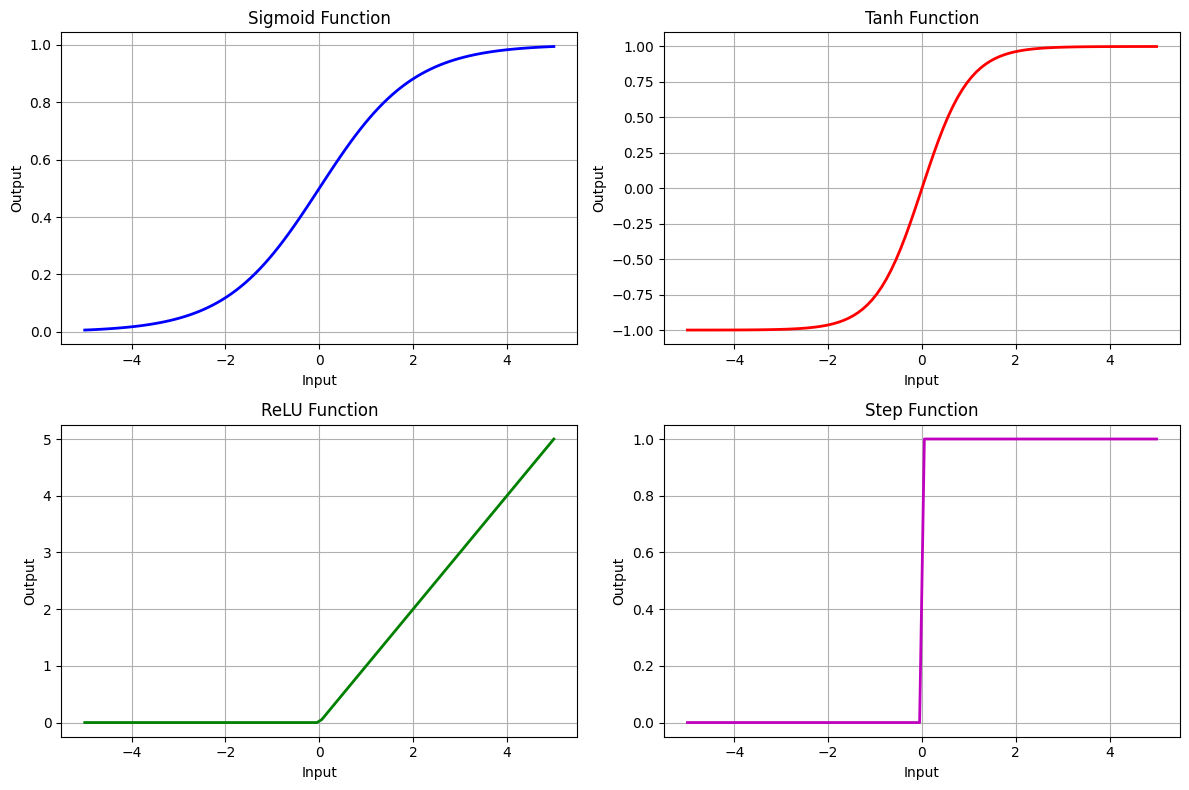

In [11]:
# Exercise 2: Implement and Compare Activation Functions

def sigmoid(x):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def tanh(x):
    """Hyperbolic tangent activation function"""
    return np.tanh(x)

def relu(x):
    """ReLU activation function"""
    return np.maximum(0, x)

def step(x):
    """Step activation function"""
    return np.where(x >= 0, 1, 0)

# Generate input values for visualization
x_values = np.linspace(-5, 5, 100)

# Calculate outputs for each activation function
sigmoid_output = sigmoid(x_values)
tanh_output = tanh(x_values)
relu_output = relu(x_values)
step_output = step(x_values)

# Plot the activation functions
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x_values, sigmoid_output, 'b-', linewidth=2)
plt.title('Sigmoid Function')
plt.grid(True)
plt.xlabel('Input')
plt.ylabel('Output')

plt.subplot(2, 2, 2)
plt.plot(x_values, tanh_output, 'r-', linewidth=2)
plt.title('Tanh Function')
plt.grid(True)
plt.xlabel('Input')
plt.ylabel('Output')

plt.subplot(2, 2, 3)
plt.plot(x_values, relu_output, 'g-', linewidth=2)
plt.title('ReLU Function')
plt.grid(True)
plt.xlabel('Input')
plt.ylabel('Output')

plt.subplot(2, 2, 4)
plt.plot(x_values, step_output, 'm-', linewidth=2)
plt.title('Step Function')
plt.grid(True)
plt.xlabel('Input')
plt.ylabel('Output')

plt.tight_layout()
plt.show()

## Part 3: Multi-Layer Perceptron (MLP)

A Multi-Layer Perceptron consists of:
- Input layer
- One or more hidden layers
- Output layer

Each layer applies weights, biases, and activation functions to transform the data.

In [12]:
# Exercise 3: Build a Simple Neural Network

class SimpleNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        """Initialize neural network with random weights and biases"""
        # Initialize weights for hidden layer
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))

        # Initialize weights for output layer
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def forward(self, X):
        """Forward propagation through the network"""
        # Hidden layer
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)

        # Output layer
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)

        return self.a2

    def predict(self, X):
        """Make predictions"""
        output = self.forward(X)
        return (output > 0.5).astype(int)

# Create and test the neural network
nn = SimpleNeuralNetwork(input_size=2, hidden_size=4, output_size=1)

# Test with sample data
X_test = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
predictions = nn.predict(X_test)

print("Neural Network Architecture:")
print(f"Input size: 2, Hidden size: 4, Output size: 1")
print(f"\nTest inputs:")
print(X_test)
print(f"\nPredictions:")
print(predictions.flatten())

Neural Network Architecture:
Input size: 2, Hidden size: 4, Output size: 1

Test inputs:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Predictions:
[0 0 0 0]


## Part 4: Training a Neural Network

Training involves:
1. Forward propagation
2. Loss calculation
3. Backward propagation (gradient computation)
4. Weight updates using gradient descent

In [13]:
# Exercise 4: Implement Training Logic

def binary_crossentropy_loss(y_true, y_pred):
    """Calculate binary cross-entropy loss"""
    # Add small epsilon to avoid log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def sigmoid_derivative(x):
    """Derivative of sigmoid function"""
    s = sigmoid(x)
    return s * (1 - s)

class TrainableNeuralNetwork(SimpleNeuralNetwork):
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        super().__init__(input_size, hidden_size, output_size)
        self.learning_rate = learning_rate

    def backward(self, X, y):
        """Backward propagation to compute gradients"""
        m = X.shape[0]

        # Compute gradients for output layer
        dz2 = self.a2 - y
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)

        # Compute gradients for hidden layer
        dz1 = np.dot(dz2, self.W2.T) * sigmoid_derivative(self.z1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)

        return dW1, db1, dW2, db2

    def update_weights(self, dW1, db1, dW2, db2):
        """Update weights using gradient descent"""
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    def train_step(self, X, y):
        """Single training step"""
        # Forward pass
        output = self.forward(X)

        # Calculate loss
        loss = binary_crossentropy_loss(y, output)

        # Backward pass
        dW1, db1, dW2, db2 = self.backward(X, y)

        # Update weights
        self.update_weights(dW1, db1, dW2, db2)

        return loss

# Test the training step
trainable_nn = TrainableNeuralNetwork(input_size=2, hidden_size=4, output_size=1)

# Create sample training data
X_train = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_train = np.array([[0], [0], [0], [1]])  # AND gate

# Perform one training step
initial_loss = binary_crossentropy_loss(y_train, trainable_nn.forward(X_train))
trainable_nn.train_step(X_train, y_train)
final_loss = binary_crossentropy_loss(y_train, trainable_nn.forward(X_train))

print(f"Initial loss: {initial_loss:.4f}")
print(f"Final loss after one step: {final_loss:.4f}")

Initial loss: 0.6909
Final loss after one step: 0.6897


## Part 5: Complete Training Example

Let's train our neural network on a simple classification problem and visualize the results.

In [14]:
# Exercise 5: Complete Training Loop

def train_network(X, y, epochs=1000, learning_rate=0.1):
    """Train the neural network and return training history"""
    nn = TrainableNeuralNetwork(input_size=X.shape[1], hidden_size=4,
                               output_size=1, learning_rate=learning_rate)

    losses = []
    accuracies = []

    for epoch in range(epochs):
        # Training step
        loss = nn.train_step(X, y)
        losses.append(loss)

        # Calculate accuracy
        predictions = nn.predict(X)
        accuracy = np.mean(predictions == y)
        accuracies.append(accuracy)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {loss:.4f}, Accuracy = {accuracy:.4f}")

    return nn, losses, accuracies

# Generate a synthetic dataset
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, n_clusters_per_class=1,
                           random_state=42)

# Reshape y for compatibility
y = y.reshape(-1, 1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the network
print("Training the neural network...")
trained_nn, losses, accuracies = train_network(X_train, y_train, epochs=1000, learning_rate=0.1)

# Evaluate on test set
test_predictions = trained_nn.predict(X_test)
test_accuracy = np.mean(test_predictions == y_test)

print(f"\nTest Accuracy: {test_accuracy:.4f}")

Training the neural network...
Epoch 0: Loss = 0.6934, Accuracy = 0.4813
Epoch 100: Loss = 0.6923, Accuracy = 0.5188
Epoch 200: Loss = 0.6906, Accuracy = 0.5188
Epoch 300: Loss = 0.6758, Accuracy = 0.5188
Epoch 400: Loss = 0.5944, Accuracy = 0.7875
Epoch 500: Loss = 0.4717, Accuracy = 0.8313
Epoch 600: Loss = 0.4069, Accuracy = 0.8562
Epoch 700: Loss = 0.3809, Accuracy = 0.8500
Epoch 800: Loss = 0.3701, Accuracy = 0.8375
Epoch 900: Loss = 0.3653, Accuracy = 0.8375

Test Accuracy: 0.8500


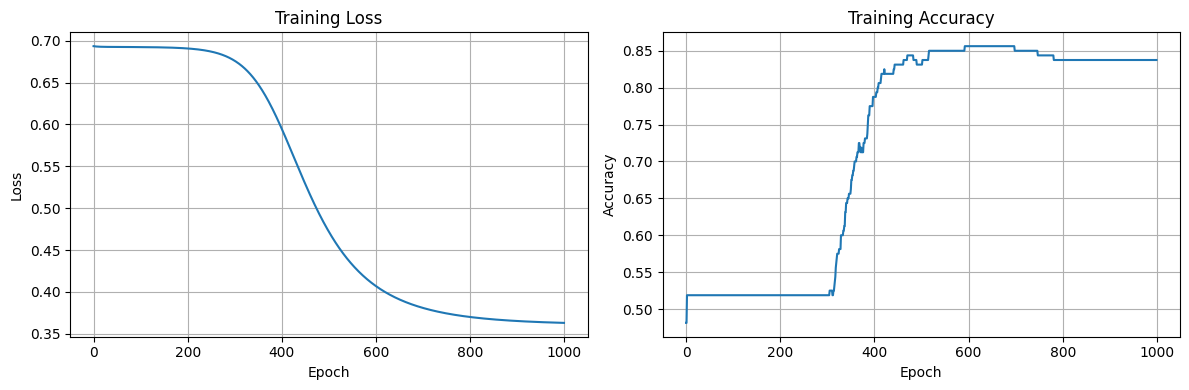

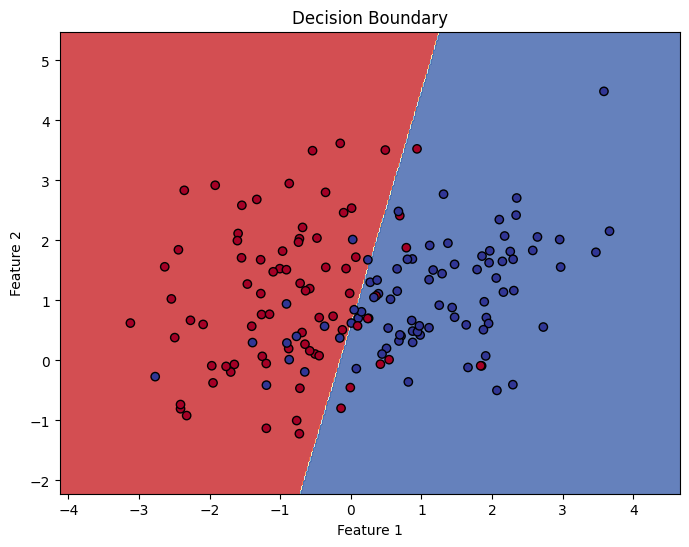

In [15]:
# Visualize Training Progress and Results

# Plot training loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(losses)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Accuracy plot
ax2.plot(accuracies)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Visualize decision boundary
def plot_decision_boundary(nn, X, y):
    """Plot decision boundary of the neural network"""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict for each point in the mesh
    Z = nn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot contour and training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap=plt.cm.RdYlBu, edgecolors='black')
    plt.title('Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot decision boundary
plot_decision_boundary(trained_nn, X_train, y_train)

## Part 6: Exercises and Questions

### Exercise 1:
Modify the `SimplePerceptron` class to use different activation functions (sigmoid, tanh, ReLU) and compare their outputs on the same input.

### Exercise 2:
Experiment with different learning rates in the training loop. What happens when the learning rate is too high or too low?

### Exercise 3:
Add more hidden layers to the neural network. How does this affect the training and performance?

### Exercise 4:
Implement a different loss function (e.g., mean squared error) and compare it with binary cross-entropy.

### Questions to Consider:
1. Why do we use activation functions in neural networks?
2. What is the purpose of the bias term?
3. How does the number of hidden units affect the model's capacity?
4. What is overfitting and how can we prevent it?

In [16]:
# Solution Space for Exercises
# Use this cell to work on the exercises above

# Exercise 1: Different activation functions in perceptron
class AdvancedPerceptron(SimplePerceptron):
    def __init__(self, n_features, activation='step'):
        super().__init__(n_features)
        self.activation = activation

    def activate(self, x):
        """Apply selected activation function"""
        if self.activation == 'step':
            return self.step_function(x)
        elif self.activation == 'sigmoid':
            return sigmoid(x)
        elif self.activation == 'tanh':
            return tanh(x)
        elif self.activation == 'relu':
            return relu(x)
        else:
            return x

    def predict(self, X):
        linear_output = self.linear_output(X)
        return self.activate(linear_output)

# Test different activation functions
test_input = np.array([1.0, -0.5])
activations = ['step', 'sigmoid', 'tanh', 'relu']

print("Testing different activation functions:")
for activation in activations:
    p = AdvancedPerceptron(2, activation=activation)
    pred = p.predict(test_input)
    print(f"{activation}: {pred}")

print("\nUse this space to work on the other exercises!")

Testing different activation functions:
step: 0
sigmoid: 0.5016319503033828
tanh: 0.0003490356398901798
relu: 0.0

Use this space to work on the other exercises!
